In [8]:
from google.colab import drive

drive.mount("/content/drive")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [9]:
import os

model_path = "/content/drive/MyDrive/Plant_Disease_Detection/models/cnn_baseline_final.keras"

print("Model exists:", os.path.exists(model_path))


Model exists: True


In [10]:
model = tf.keras.models.load_model(model_path)

print("Model loaded successfully.")

Model loaded successfully.


In [11]:
import tensorflow as tf
print(tf.__version__)
print(tf.config.list_physical_devices('GPU'))

2.20.0
[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [13]:
!git clone https://github.com/spMohanty/PlantVillage-Dataset.git

fatal: destination path 'PlantVillage-Dataset' already exists and is not an empty directory.


In [14]:
import os
dataset_path = "/content/PlantVillage-Dataset"
os.listdir(dataset_path)

['raw',
 'generate_mapstring.py',
 'README.md',
 '.git',
 'scripts',
 '.gitignore',
 'leaf-map.json',
 'plant_village.py',
 'generated_for_paper',
 'generate_lmdb.sh',
 'generate_data_for_SVM.py',
 'data_distribution_for_SVM',
 'utils',
 'README_HF.md',
 'CITATION.cff',
 'logs',
 'leaf_grouping']

In [15]:
import os

raw_path = "/content/PlantVillage-Dataset/raw"

print(os.listdir(raw_path))

['grayscale', 'color', 'segmented']


In [84]:
color_path = "/content/PlantVillage-Dataset/raw/color"

print(os.listdir(color_path))

['Strawberry___healthy', 'Tomato___Tomato_Yellow_Leaf_Curl_Virus', 'Squash___Powdery_mildew', 'Cherry_(including_sour)___Powdery_mildew', 'Corn_(maize)___Northern_Leaf_Blight', 'Apple___Apple_scab', 'Raspberry___healthy', 'Tomato___Septoria_leaf_spot', 'Apple___healthy', 'Pepper,_bell___healthy', 'Apple___Black_rot', 'Grape___Black_rot', 'Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot', 'Tomato___Spider_mites Two-spotted_spider_mite', 'Tomato___Target_Spot', 'Soybean___healthy', 'Cherry_(including_sour)___healthy', 'Tomato___Bacterial_spot', 'Blueberry___healthy', 'Tomato___Early_blight', 'Corn_(maize)___Common_rust_', 'Tomato___Late_blight', 'Peach___healthy', 'Grape___Leaf_blight_(Isariopsis_Leaf_Spot)', 'Potato___healthy', 'Tomato___Leaf_Mold', 'Pepper,_bell___Bacterial_spot', 'Potato___Late_blight', 'Tomato___healthy', 'Strawberry___Leaf_scorch', 'Potato___Early_blight', 'Grape___Esca_(Black_Measles)', 'Grape___healthy', 'Orange___Haunglongbing_(Citrus_greening)', 'Peach___Bact

In [85]:
class_counts = {}

for class_name in os.listdir(color_path):
    class_path = os.path.join(color_path, class_name)

    if os.path.isdir(class_path):
        class_counts[class_name] = len(os.listdir(class_path))

print("Total Classes:", len(class_counts))

for class_name, count in class_counts.items():
    print(f"{class_name}: {count} images")

Total Classes: 38
Strawberry___healthy: 456 images
Tomato___Tomato_Yellow_Leaf_Curl_Virus: 5357 images
Squash___Powdery_mildew: 1835 images
Cherry_(including_sour)___Powdery_mildew: 1052 images
Corn_(maize)___Northern_Leaf_Blight: 985 images
Apple___Apple_scab: 630 images
Raspberry___healthy: 371 images
Tomato___Septoria_leaf_spot: 1771 images
Apple___healthy: 1645 images
Pepper,_bell___healthy: 1478 images
Apple___Black_rot: 621 images
Grape___Black_rot: 1180 images
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot: 513 images
Tomato___Spider_mites Two-spotted_spider_mite: 1676 images
Tomato___Target_Spot: 1404 images
Soybean___healthy: 5090 images
Cherry_(including_sour)___healthy: 854 images
Tomato___Bacterial_spot: 2127 images
Blueberry___healthy: 1502 images
Tomato___Early_blight: 1000 images
Corn_(maize)___Common_rust_: 1192 images
Tomato___Late_blight: 1909 images
Peach___healthy: 360 images
Grape___Leaf_blight_(Isariopsis_Leaf_Spot): 1076 images
Potato___healthy: 152 images
To

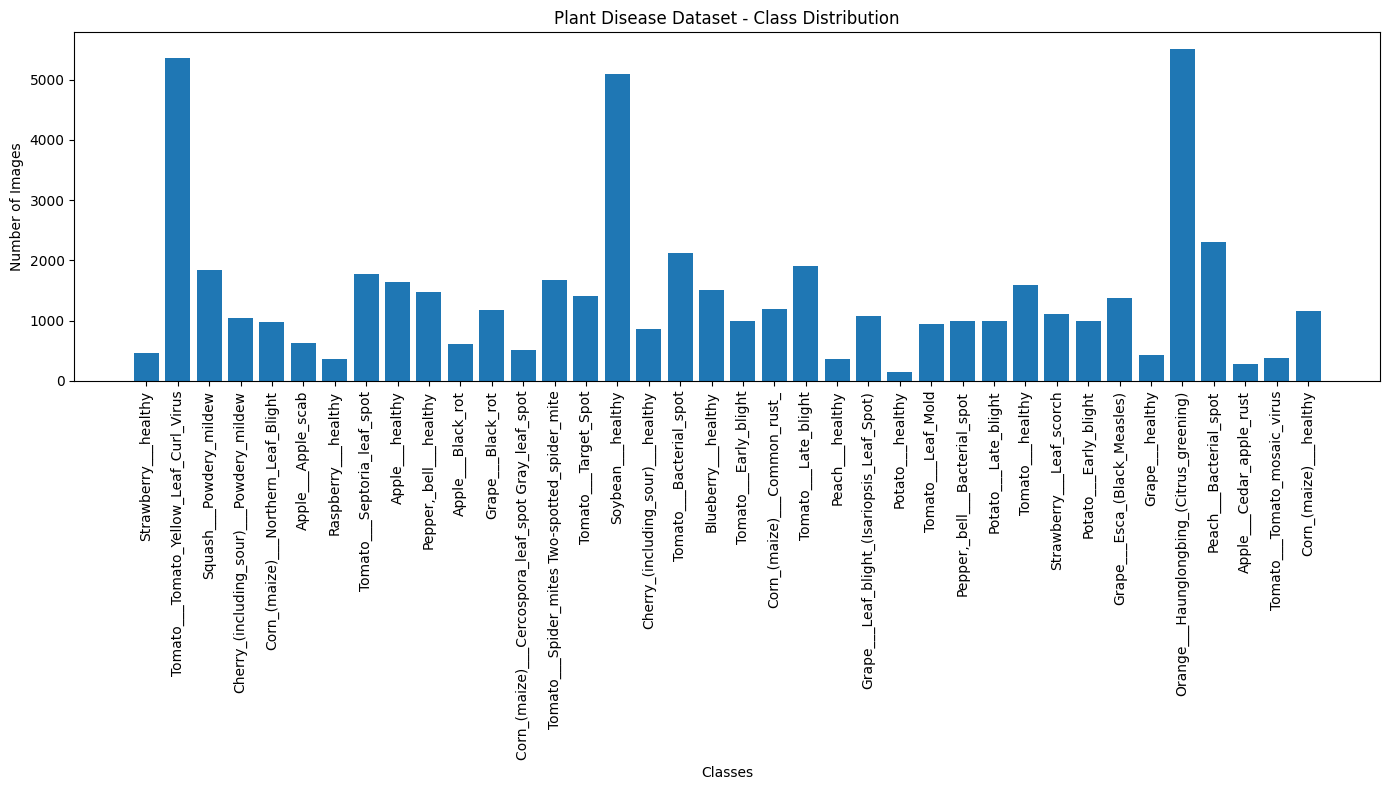

In [86]:
import matplotlib.pyplot as plt
plt.figure(figsize=(14, 8))
plt.bar(range(len(class_counts)), class_counts.values())
plt.xticks(range(len(class_counts)), class_counts.keys(), rotation=90)
plt.xlabel("Classes")
plt.ylabel("Number of Images")
plt.title("Plant Disease Dataset - Class Distribution")

plt.tight_layout()
plt.show()

## 3. Exploratory Data Analysis

### 3.1 Class Distribution


### Observations

- The dataset contains 38 classes.
- The number of images varies considerably across classes.
- Orange___Haunglongbing_(Citrus_greening) has the highest number of images.
- Potato___healthy has the lowest number of images.
- The dataset is therefore imbalanced.

In [20]:
import random # images ko randomly shuffle ke liye
import shutil #copy from one folder to another

In [21]:
source_dir = "/content/PlantVillage-Dataset/raw/color"

In [22]:
output_dir = "/content/plant_disease_data"

In [23]:
random.seed(42)

In [24]:
# Train, validation aur test folders create karna
for split in ["train", "validation", "test"]:
    os.makedirs(os.path.join(output_dir, split), exist_ok=True)

In [25]:
for class_name in os.listdir(source_dir):

    class_source_dir = os.path.join(source_dir, class_name)

    if not os.path.isdir(class_source_dir):
        continue

    images = os.listdir(class_source_dir)

    random.shuffle(images)

    total_images = len(images)

    train_end = int(0.70 * total_images)

    validation_end = int(0.85 * total_images)

    train_images = images[:train_end]
    validation_images = images[train_end:validation_end]
    test_images = images[validation_end:]

    for split in ["train", "validation", "test"]:
        os.makedirs(
            os.path.join(output_dir, split, class_name),
            exist_ok=True
        )

    for image in train_images:
        shutil.copy2(
            os.path.join(class_source_dir, image),
            os.path.join(output_dir, "train", class_name, image)
        )

    for image in validation_images:
        shutil.copy2(
            os.path.join(class_source_dir, image),
            os.path.join(output_dir, "validation", class_name, image)
        )

    for image in test_images:
        shutil.copy2(
            os.path.join(class_source_dir, image),
            os.path.join(output_dir, "test", class_name, image)
        )

print("Dataset splitting completed!")

Dataset splitting completed!


In [26]:
from collections import Counter

base_dir = "/content/plant_disease_data"

for split in ["train", "validation", "test"]:

    split_dir = os.path.join(base_dir, split)

    class_counts = {}

    for class_name in os.listdir(split_dir):

        class_path = os.path.join(split_dir, class_name)

        if os.path.isdir(class_path):
            class_counts[class_name] = len(os.listdir(class_path))

    total_images = sum(class_counts.values())

    print(f"\n{split.upper()}")
    print("-" * 30)
    print("Number of classes:", len(class_counts))
    print("Total images:", total_images)


TRAIN
------------------------------
Number of classes: 38
Total images: 37997

VALIDATION
------------------------------
Number of classes: 38
Total images: 8146

TEST
------------------------------
Number of classes: 38
Total images: 8162


Observations:

The dataset contains a total of 54,305 images across 38 classes.
The dataset was divided into 70% training, 15% validation, and 15% testing sets.
The training set contains 37,997 images, while the validation and test sets contain 8,146 and 8,162 images, respectively.
All three splits contain all 38 classes, ensuring that every class is represented during training, validation, and testing.
The split maintains approximately the desired 70:15:15 distribution.

Class: Strawberry___healthy
Image: ff7ccace-1453-44e8-8580-3263c2952ea8___RS_HL 2006.JPG
Image size: (256, 256)
Image mode: RGB


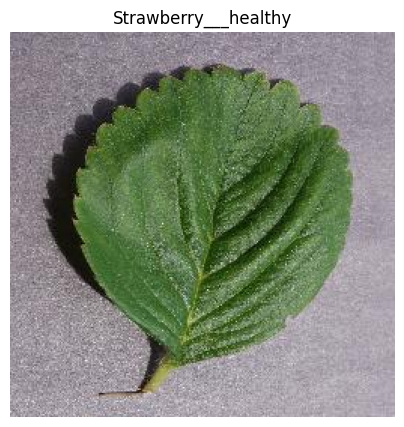

In [28]:
from PIL import Image

train_dir = "/content/plant_disease_data/train"

class_name = os.listdir(train_dir)[0]

class_dir = os.path.join(train_dir, class_name)

image_name = os.listdir(class_dir)[0]

image_path = os.path.join(class_dir, image_name)

image = Image.open(image_path)

print("Class:", class_name)
print("Image:", image_name)
print("Image size:", image.size)
print("Image mode:", image.mode)

plt.figure(figsize=(5, 5))
plt.imshow(image)
plt.title(class_name)
plt.axis("off")
plt.show()

The sample images have a resolution of 256 × 256 pixels and are stored in RGB format,
 indicating that each image contains three color channels: Red, Green, and Blue.

In [30]:
import tensorflow as tf

IMG_SIZE = (224, 224) ## for transfer learning
BATCH_SIZE = 32

train_ds = tf.keras.utils.image_dataset_from_directory(
    os.path.join(output_dir, "train"),
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=True,
    seed=42
)

validation_ds = tf.keras.utils.image_dataset_from_directory(
    os.path.join(output_dir, "validation"),
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    os.path.join(output_dir, "test"),
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

Found 37997 files belonging to 38 classes.
Found 8146 files belonging to 38 classes.
Found 8162 files belonging to 38 classes.


In [31]:
for images, labels in train_ds.take(1): ##training data me se ek batch liya
    print("Images shape:", images.shape)
    print("Labels shape:", labels.shape)
    print("Image data type:", images.dtype)
    print("Label data type:", labels.dtype)

Images shape: (32, 224, 224, 3)
Labels shape: (32,)
Image data type: <dtype: 'float32'>
Label data type: <dtype: 'int32'>


In [32]:
normalization_layer = tf.keras.layers.Rescaling(1./255)

train_ds = train_ds.map(
    lambda images, labels: (normalization_layer(images), labels)
)

validation_ds = validation_ds.map(
    lambda images, labels: (normalization_layer(images), labels)
)

test_ds = test_ds.map(
    lambda images, labels: (normalization_layer(images), labels)
)

In [33]:
for images, labels in train_ds.take(1):
    print("Minimum pixel value:", tf.reduce_min(images).numpy())
    print("Maximum pixel value:", tf.reduce_max(images).numpy())

Minimum pixel value: 0.0
Maximum pixel value: 0.99733853


In [34]:
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.1),
    tf.keras.layers.RandomZoom(0.1)
])

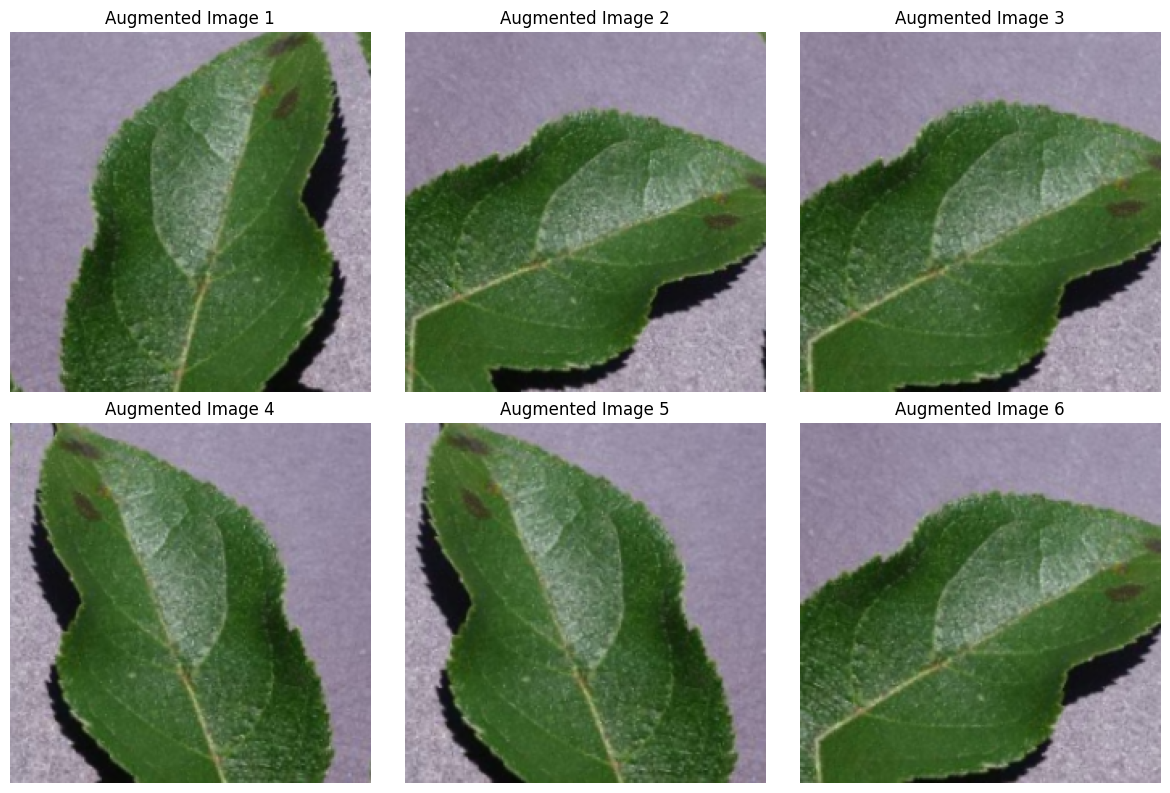

In [35]:
for images, labels in train_ds.take(1):
    sample_image = images[0]
    sample_label = labels[0]

plt.figure(figsize=(12, 8))

for i in range(6):
    augmented_image = data_augmentation(
        tf.expand_dims(sample_image, axis=0),
        training=True
    )[0]

    plt.subplot(2, 3, i + 1)
    plt.imshow(augmented_image)
    plt.title(f"Augmented Image {i + 1}")
    plt.axis("off")

plt.tight_layout()
plt.show()

###Observation:
The augmented images preserve the important visual characteristics of the original leaf while introducing variations in orientation and scale.
 The transformations appear realistic and do not significantly distort the disease-related features.
  Therefore, the selected augmentation techniques are suitable for improving the model's ability to generalize to variations in input images.

In [37]:
class_names = sorted([
    class_name
    for class_name in os.listdir("/content/plant_disease_data/train")
    if os.path.isdir(os.path.join("/content/plant_disease_data/train", class_name))
])

num_classes = len(class_names)

print("Number of classes:", num_classes)

Number of classes: 38


In [34]:
model = tf.keras.Sequential([

    tf.keras.layers.Input(shape=(224, 224, 3)),

    data_augmentation,

    tf.keras.layers.Conv2D(32, (3, 3), activation="relu"),
    tf.keras.layers.MaxPooling2D((2, 2)),

    tf.keras.layers.Conv2D(64, (3, 3), activation="relu"),
    tf.keras.layers.MaxPooling2D((2, 2)),

    tf.keras.layers.Conv2D(128, (3, 3), activation="relu"),
    tf.keras.layers.MaxPooling2D((2, 2)),

    tf.keras.layers.Conv2D(256, (3, 3), activation="relu"),
    tf.keras.layers.MaxPooling2D((2, 2)),

    tf.keras.layers.GlobalAveragePooling2D(),

    tf.keras.layers.Dense(128, activation="relu"),

    tf.keras.layers.Dropout(0.4),

    tf.keras.layers.Dense(num_classes, activation="softmax")
])

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 24, 24, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 12, 12, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 38)             │         4,902 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 426,214 (1.63 MB)

 Trainable params: 426,214 (1.63 MB)

 Non-trainable params: 0 (0.00 B)

In [35]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [36]:
history = model.fit(
    train_ds,
    validation_data=validation_ds,
    epochs=15
)

Epoch 1/15
1188/1188 ━━━━━━━━━━━━━━━━━━━━ 86s 66ms/step - accuracy: 0.3101 - loss: 2.5193 - val_accuracy: 0.4202 - val_loss: 1.9602
Epoch 2/15
1188/1188 ━━━━━━━━━━━━━━━━━━━━ 81s 68ms/step - accuracy: 0.5258 - loss: 1.6254 - val_accuracy: 0.5849 - val_loss: 1.4123
Epoch 3/15
1188/1188 ━━━━━━━━━━━━━━━━━━━━ 82s 67ms/step - accuracy: 0.6761 - loss: 1.0718 - val_accuracy: 0.7598 - val_loss: 0.7516
Epoch 4/15
1188/1188 ━━━━━━━━━━━━━━━━━━━━ 82s 67ms/step - accuracy: 0.7441 - loss: 0.8227 - val_accuracy: 0.7512 - val_loss: 0.8011
Epoch 5/15
1188/1188 ━━━━━━━━━━━━━━━━━━━━ 80s 68ms/step - accuracy: 0.7850 - loss: 0.6815 - val_accuracy: 0.8468 - val_loss: 0.4666
Epoch 6/15
1188/1188 ━━━━━━━━━━━━━━━━━━━━ 79s 66ms/step - accuracy: 0.8158 - loss: 0.5752 - val_accuracy: 0.8720 - val_loss: 0.3928
Epoch 7/15
1188/1188 ━━━━━━━━━━━━━━━━━━━━ 81s 68ms/step - accuracy: 0.8398 - loss: 0.5082 - val_accuracy: 0.8991 - val_loss: 0.3193
Epoch 8/15
1188/1188 ━━━━━━━━━━━━━━━━━━━━ 81s 67ms/step - accuracy: 0.8574 -

In [37]:
model.save("/content/cnn_baseline_final.keras")

print("Model saved successfully.")

Model saved successfully.


In [42]:
history_data = {
    "accuracy": [
        0.3058, 0.5325, 0.6702, 0.7348, 0.7786,
        0.8095, 0.8312, 0.8539, 0.8720, 0.8825,
        0.8897, 0.8990, 0.9085, 0.9120, 0.9201
    ],
    "loss": [
        2.5356, 1.5825, 1.0926, 0.8661, 0.7141,
        0.6037, 0.5363, 0.4666, 0.4088, 0.3695,
        0.3456, 0.3183, 0.2875, 0.2743, 0.2497
    ],
    "val_accuracy": [
        0.4266, 0.6005, 0.6099, 0.7625, 0.8319,
        0.8674, 0.8993, 0.8851, 0.9063, 0.9207,
        0.9219, 0.9058, 0.9333, 0.9481, 0.9363
    ],
    "val_loss": [
        2.0116, 1.3678, 1.3437, 0.7596, 0.5278,
        0.4310, 0.3252, 0.3645, 0.2910, 0.2493,
        0.2482, 0.3021, 0.1955, 0.1700, 0.2135
    ]
}

print("Training history restored for 15 epochs.")

Training history restored for 15 epochs.


In [43]:
class History:
    def __init__(self, history):
        self.history = history

history = History(history_data)

print("History object recreated successfully.")

History object recreated successfully.


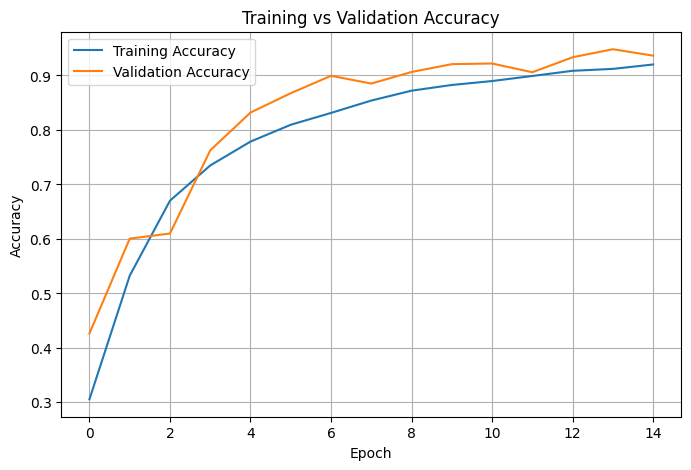

In [44]:

import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.legend()
plt.grid(True)

plt.show()

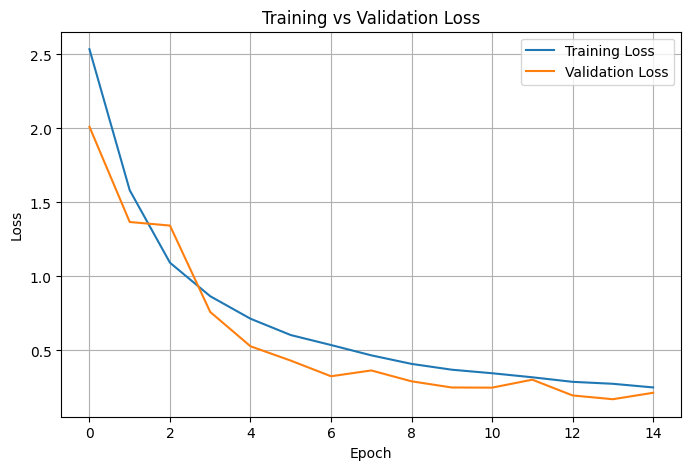

In [45]:
plt.figure(figsize=(8, 5))

plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.grid(True)

plt.show()

###Observations:
The training and validation losses show a consistent downward trend across the epochs.
 This indicates that the model is progressively learning useful features from the images.
  The validation loss does not show a sustained increase while the training loss continues to decrease,
   suggesting that there is no strong indication of overfitting within the 15 training epochs.

In [47]:
model_path = "/content/drive/MyDrive/Plant_Disease_Detection/models/cnn_baseline_final.keras"

model.save(model_path)

print("Model saved at:")
print(model_path)

Model saved at:
/content/drive/MyDrive/Plant_Disease_Detection/models/cnn_baseline_final.keras


In [48]:
test_loss, test_accuracy = model.evaluate(test_ds)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

256/256 ━━━━━━━━━━━━━━━━━━━━ 13s 39ms/step - accuracy: 0.9613 - loss: 0.1193
Test Loss: 0.119334876537323
Test Accuracy: 0.9612839818000793


In [49]:
from sklearn.metrics import classification_report
import numpy as np

y_true = []
y_pred = []

for images, labels in test_ds:
    predictions = model.predict(images, verbose=0)

    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(predictions, axis=1))

print(classification_report(
    y_true,
    y_pred,
    target_names=class_names,
    digits=4
))

                                                    precision    recall  f1-score   support

                                Apple___Apple_scab     0.9551    0.8947    0.9239        95
                                 Apple___Black_rot     0.8304    0.9894    0.9029        94
                          Apple___Cedar_apple_rust     1.0000    0.9286    0.9630        42
                                   Apple___healthy     0.9750    0.9474    0.9610       247
                               Blueberry___healthy     0.9698    0.9956    0.9825       226
          Cherry_(including_sour)___Powdery_mildew     0.9873    0.9810    0.9841       158
                 Cherry_(including_sour)___healthy     0.9699    1.0000    0.9847       129
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot     0.7083    0.8831    0.7861        77
                       Corn_(maize)___Common_rust_     0.9944    0.9888    0.9916       179
               Corn_(maize)___Northern_Leaf_Blight     0.9173    0.8243    0.86

###Classification Report Observations:

The baseline CNN achieved an overall test accuracy of 95.52% with a macro-average F1-score of 94.02%.
 The high macro F1-score indicates that the model performs well across most of the 38 classes, rather than achieving high accuracy only on the majority classes.

Several classes, including Corn Healthy, Potato Early Blight, Peach Healthy, and Orange Citrus Greening, achieved F1-scores close to or above 0.98.
 However, some minority classes such as Potato Healthy showed comparatively lower performance. Potato Healthy had only 23 samples in the test set, which makes its class-wise metric less stable.

The results also indicate that classes with fewer training examples may require further investigation. Therefore, a confusion matrix will be used to identify which specific classes are being confused with each other.

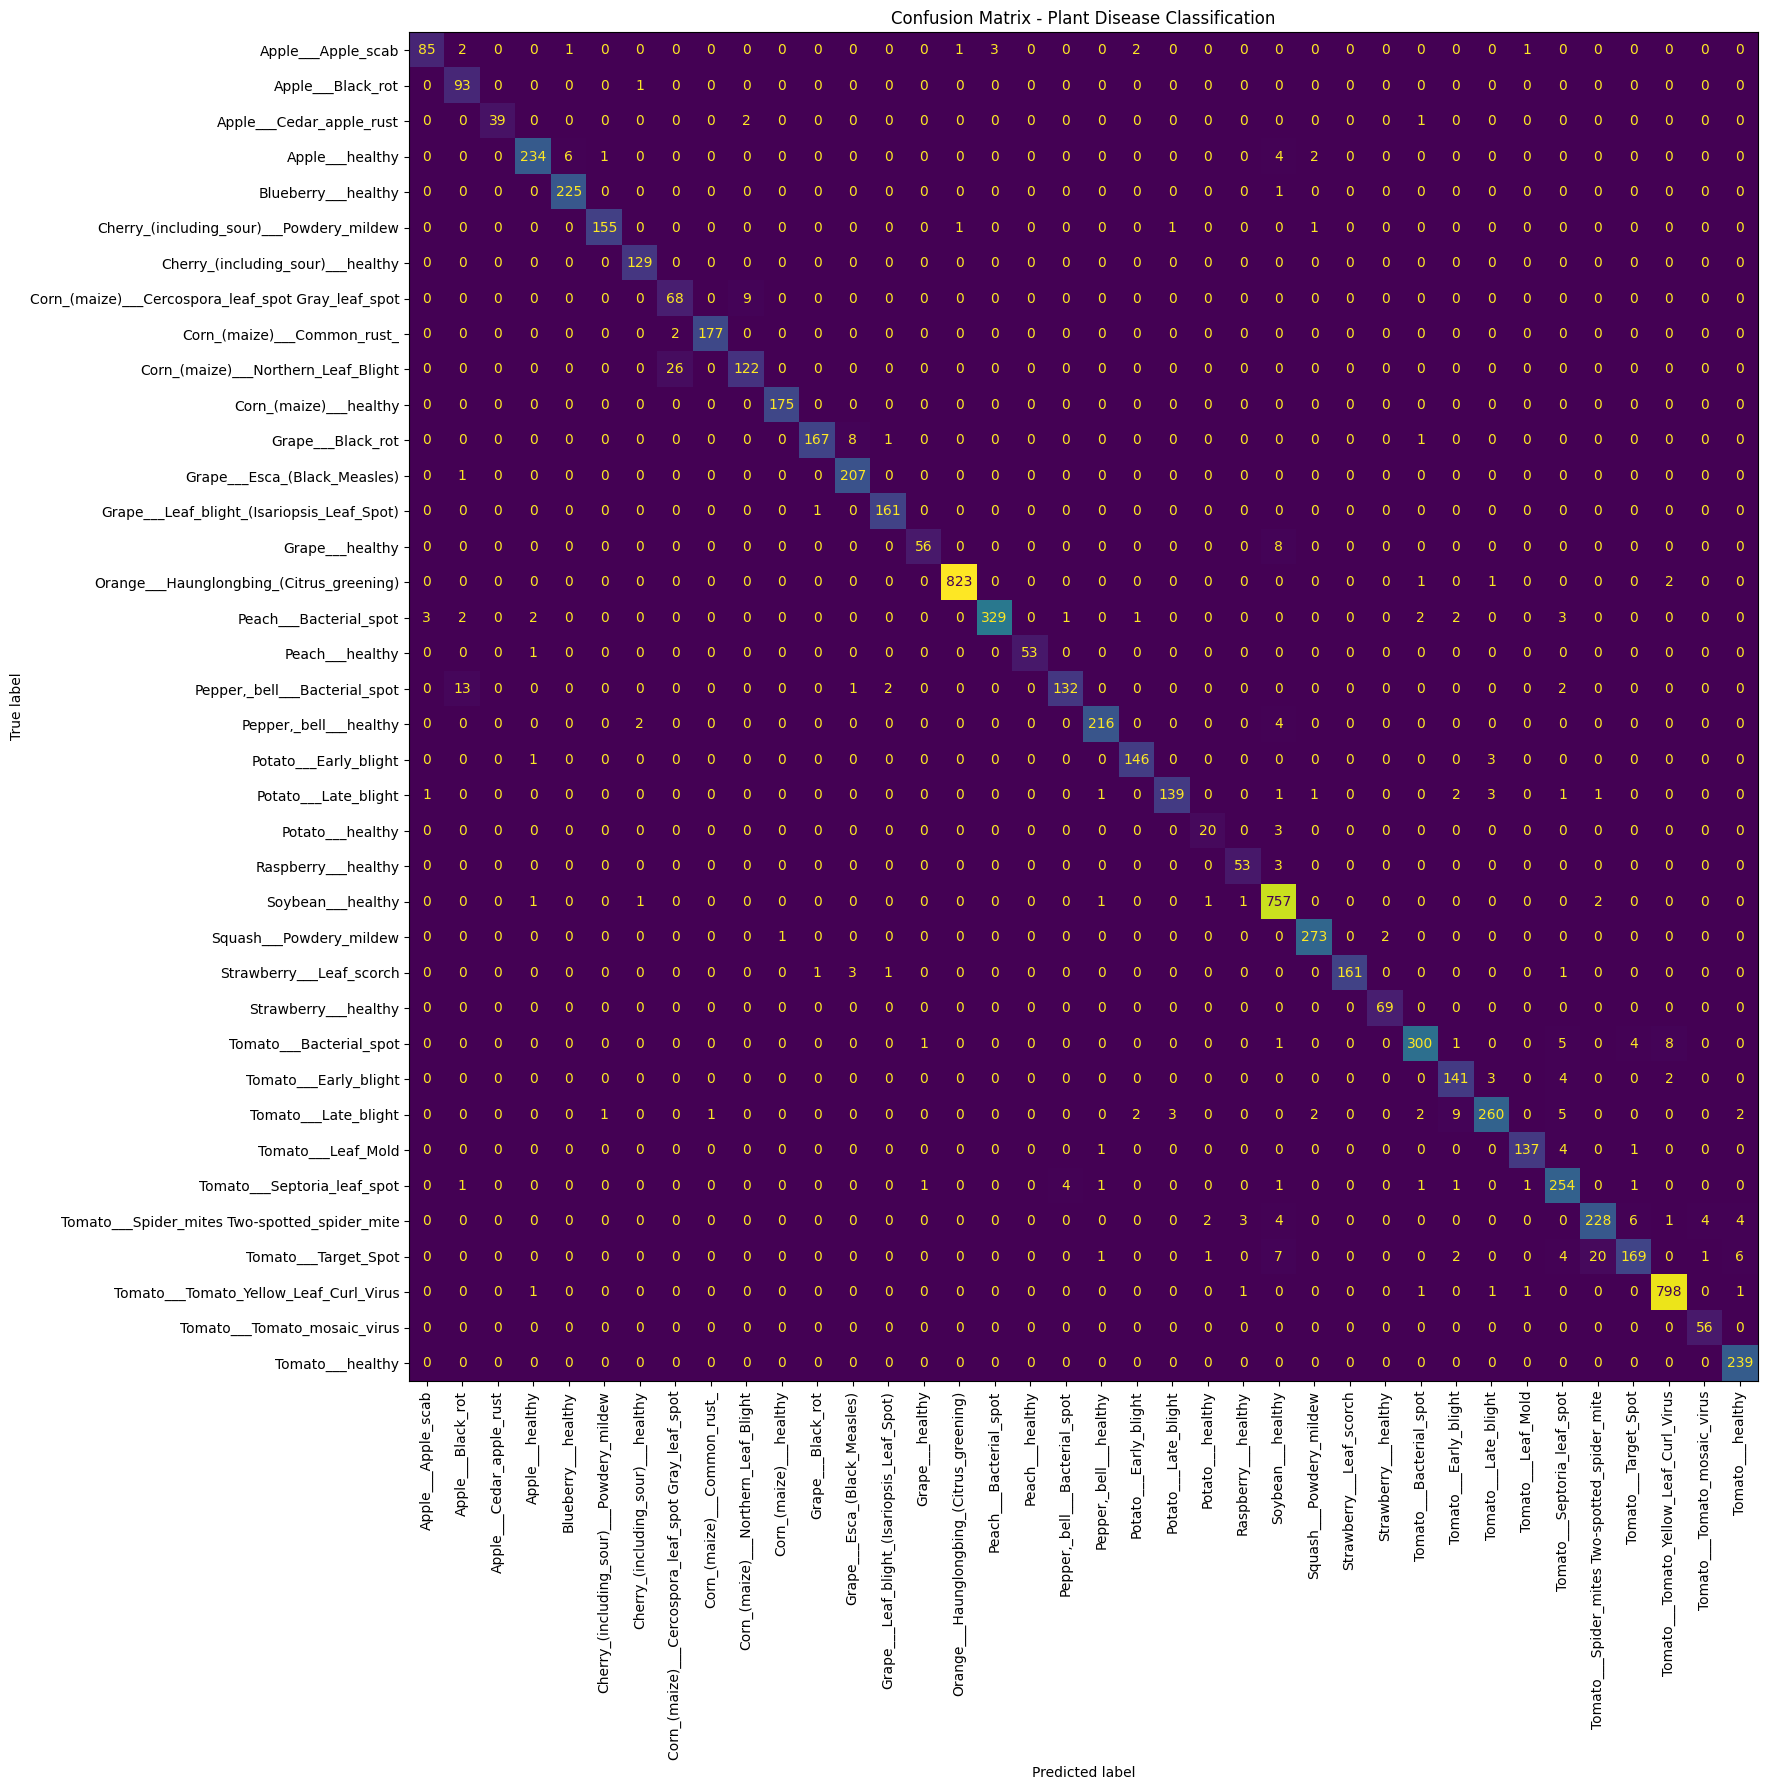

In [51]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_true, y_pred)

fig, ax = plt.subplots(figsize=(18, 18))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=class_names
)

disp.plot(
    ax=ax,
    xticks_rotation=90,
    colorbar=False
)

plt.title("Confusion Matrix - Plant Disease Classification")
plt.tight_layout()
plt.show()

###Confusion Matrix Observations:
The confusion matrix shows that most predictions lie along the diagonal,
 indicating strong classification performance across the majority of classes.
  However, some confusion is observed between visually similar disease categories,
   particularly among certain corn and tomato diseases. The model also shows relatively weaker classification for low-sample classes such as Potato Healthy.
    These observations are consistent with the class-wise precision, recall, and F1-scores obtained from the classification report.

In [53]:
wrong_indices = np.where(np.array(y_true) != np.array(y_pred))[0]

print("Total incorrect predictions:", len(wrong_indices))
print("Total test images:", len(y_true))
print(
    "Error rate:",
    len(wrong_indices) / len(y_true) * 100,
    "%"
)

Total incorrect predictions: 316
Total test images: 8162
Error rate: 3.8716000980151923 %


In [54]:
wrong_images = []
wrong_true_labels = []
wrong_pred_labels = []

for images, labels in test_ds:
    predictions = model.predict(images, verbose=0)
    predicted_labels = np.argmax(predictions, axis=1)

    for image, true_label, predicted_label in zip(
        images, labels.numpy(), predicted_labels
    ):
        if true_label != predicted_label:
            wrong_images.append(image.numpy())
            wrong_true_labels.append(true_label)
            wrong_pred_labels.append(predicted_label)

print("Wrong images collected:", len(wrong_images))

Wrong images collected: 316


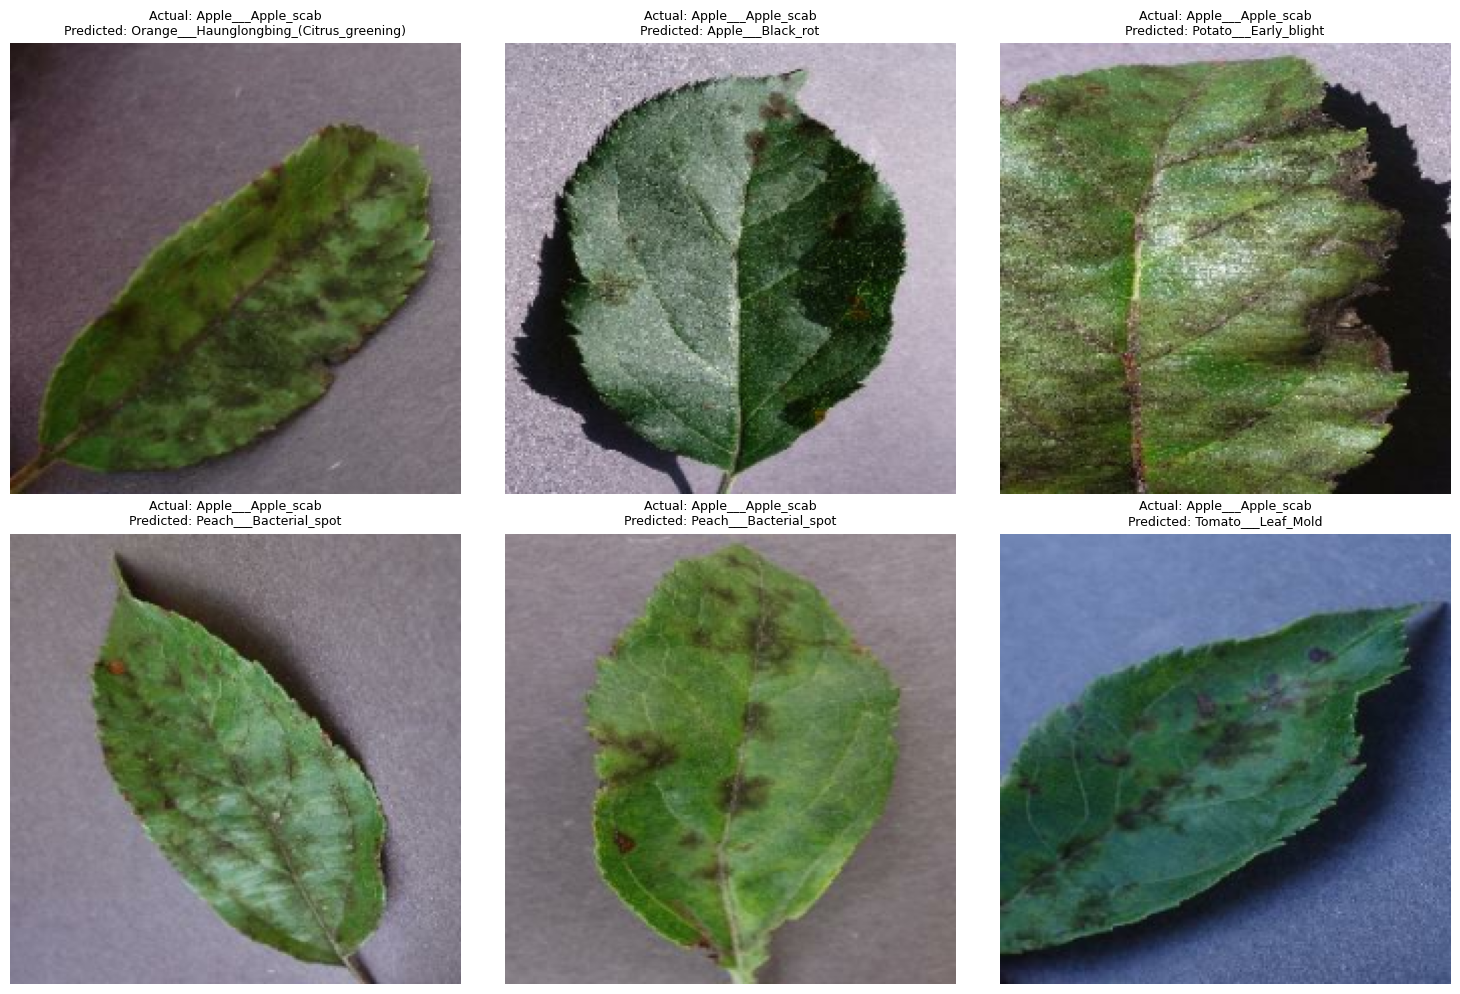

In [55]:
plt.figure(figsize=(15, 10))

for i in range(6):
    plt.subplot(2, 3, i + 1)

    plt.imshow(wrong_images[i])

    true_class = class_names[wrong_true_labels[i]]
    predicted_class = class_names[wrong_pred_labels[i]]

    plt.title(
        f"Actual: {true_class}\nPredicted: {predicted_class}",
        fontsize=9
    )

    plt.axis("off")

plt.tight_layout()
plt.show()

In [56]:
from collections import Counter

confusion_pairs = Counter(
    (class_names[true_label], class_names[pred_label])
    for true_label, pred_label in zip(y_true, y_pred)
    if true_label != pred_label
)

for (true_class, predicted_class), count in confusion_pairs.most_common(15):
    print(f"{true_class}  →  {predicted_class}: {count}")

Corn_(maize)___Northern_Leaf_Blight  →  Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot: 26
Tomato___Target_Spot  →  Tomato___Spider_mites Two-spotted_spider_mite: 20
Pepper,_bell___Bacterial_spot  →  Apple___Black_rot: 13
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot  →  Corn_(maize)___Northern_Leaf_Blight: 9
Tomato___Late_blight  →  Tomato___Early_blight: 9
Grape___Black_rot  →  Grape___Esca_(Black_Measles): 8
Grape___healthy  →  Soybean___healthy: 8
Tomato___Bacterial_spot  →  Tomato___Tomato_Yellow_Leaf_Curl_Virus: 8
Tomato___Target_Spot  →  Soybean___healthy: 7
Apple___healthy  →  Blueberry___healthy: 6
Tomato___Spider_mites Two-spotted_spider_mite  →  Tomato___Target_Spot: 6
Tomato___Target_Spot  →  Tomato___healthy: 6
Tomato___Bacterial_spot  →  Tomato___Septoria_leaf_spot: 5
Tomato___Late_blight  →  Tomato___Septoria_leaf_spot: 5
Apple___healthy  →  Soybean___healthy: 4


The error analysis showed that most misclassifications occurred between visually similar disease categories,
 particularly among corn and tomato diseases.
  The model also struggled more with some minority classes,
  indicating that both visual similarity and class imbalance can influence classification performance.
  

In [58]:
base_model = tf.keras.applications.MobileNetV2(
    input_shape=(224, 224, 3),
    include_top=False,
    weights="imagenet"
)

base_model.trainable = False

print("Base model loaded.")
print("Trainable:", base_model.trainable)

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Base model loaded.
Trainable: False


In [59]:
transfer_model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(224, 224, 3)),

    tf.keras.layers.Rescaling(2.0, offset=-1),

    data_augmentation,

    base_model,

    tf.keras.layers.GlobalAveragePooling2D(),

    tf.keras.layers.Dropout(0.3),

    tf.keras.layers.Dense(128, activation="relu"),

    tf.keras.layers.Dropout(0.3),

    tf.keras.layers.Dense(num_classes, activation="softmax")
])

transfer_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling_1 (Rescaling)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential (Sequential)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 38)             │         4,902 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,426,854 (9.26 MB)

 Trainable params: 168,870 (659.65 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [60]:
transfer_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

print("Transfer learning model compiled.")

Transfer learning model compiled.


In [61]:
checkpoint_path = "/content/drive/MyDrive/Plant_Disease_Detection/models/mobilenetv2_best.keras"

checkpoint = tf.keras.callbacks.ModelCheckpoint(
    checkpoint_path,
    monitor="val_accuracy",
    mode="max",
    save_best_only=True,
    verbose=1
)

print("Checkpoint ready.")

Checkpoint ready.


In [62]:
transfer_history = transfer_model.fit(
    train_ds,
    validation_data=validation_ds,
    epochs=10,
    callbacks=[checkpoint]
)

Epoch 1/10
1188/1188 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step - accuracy: 0.3717 - loss: 2.4995
Epoch 1: val_accuracy improved from None to 0.82053, saving model to /content/drive/MyDrive/Plant_Disease_Detection/models/mobilenetv2_best.keras

Epoch 1: finished saving model to /content/drive/MyDrive/Plant_Disease_Detection/models/mobilenetv2_best.keras
1188/1188 ━━━━━━━━━━━━━━━━━━━━ 112s 85ms/step - accuracy: 0.5265 - loss: 1.8116 - val_accuracy: 0.8205 - val_loss: 0.7242
Epoch 2/10
1187/1188 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step - accuracy: 0.7270 - loss: 0.9525
Epoch 2: val_accuracy improved from 0.82053 to 0.88362, saving model to /content/drive/MyDrive/Plant_Disease_Detection/models/mobilenetv2_best.keras

Epoch 2: finished saving model to /content/drive/MyDrive/Plant_Disease_Detection/models/mobilenetv2_best.keras
1188/1188 ━━━━━━━━━━━━━━━━━━━━ 132s 78ms/step - accuracy: 0.7527 - loss: 0.8556 - val_accuracy: 0.8836 - val_loss: 0.4437
Epoch 3/10
1187/1188 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step - ac

###Observation:
The frozen MobileNetV2 transfer-learning model achieved a best validation accuracy of 93.95% at epoch 9.
 Although this was slightly lower than the custom CNN's best validation accuracy of 94.81%,
 the transfer-learning model reached high performance rapidly.
  Since the pretrained feature extractor was kept frozen,
   the model was only able to adapt its newly added classification layers to the plant disease task.
    Further improvement can therefore be investigated through fine-tuning of selected deeper MobileNetV2 layers.

In [64]:
base_model.trainable = True

for layer in base_model.layers[:-30]:
    layer.trainable = False

print("Total MobileNetV2 layers:", len(base_model.layers))
print("Trainable layers:", sum(layer.trainable for layer in base_model.layers))

Total MobileNetV2 layers: 154
Trainable layers: 30


In [65]:
transfer_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

print("Model recompiled for fine-tuning.")

Model recompiled for fine-tuning.


In [66]:
fine_tune_checkpoint_path = "/content/drive/MyDrive/Plant_Disease_Detection/models/mobilenetv2_finetuned_best.keras"

fine_tune_checkpoint = tf.keras.callbacks.ModelCheckpoint(
    fine_tune_checkpoint_path,
    monitor="val_accuracy",
    mode="max",
    save_best_only=True,
    verbose=1
)

print("Fine-tuning checkpoint ready.")

Fine-tuning checkpoint ready.


In [67]:
fine_tune_history = transfer_model.fit(
    train_ds,
    validation_data=validation_ds,
    epochs=10,
    callbacks=[fine_tune_checkpoint]
)

Epoch 1/10
1188/1188 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step - accuracy: 0.7713 - loss: 0.7750
Epoch 1: val_accuracy improved from None to 0.93923, saving model to /content/drive/MyDrive/Plant_Disease_Detection/models/mobilenetv2_finetuned_best.keras

Epoch 1: finished saving model to /content/drive/MyDrive/Plant_Disease_Detection/models/mobilenetv2_finetuned_best.keras
1188/1188 ━━━━━━━━━━━━━━━━━━━━ 131s 97ms/step - accuracy: 0.8344 - loss: 0.5432 - val_accuracy: 0.9392 - val_loss: 0.1831
Epoch 2/10
1187/1188 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step - accuracy: 0.8911 - loss: 0.3401
Epoch 2: val_accuracy improved from 0.93923 to 0.95126, saving model to /content/drive/MyDrive/Plant_Disease_Detection/models/mobilenetv2_finetuned_best.keras

Epoch 2: finished saving model to /content/drive/MyDrive/Plant_Disease_Detection/models/mobilenetv2_finetuned_best.keras
1188/1188 ━━━━━━━━━━━━━━━━━━━━ 114s 96ms/step - accuracy: 0.8977 - loss: 0.3186 - val_accuracy: 0.9513 - val_loss: 0.1488
Epoch 3/10
1187/118

###Fine-tuning Observation:
Fine-tuning significantly improved the performance of the MobileNetV2 model.
 After unfreezing the last 30 layers and training with a low learning rate of 1e-5,
  the validation accuracy increased from 93.95% in the frozen transfer-learning phase to 97.36%.
   The validation loss also decreased to 0.0760.
    This demonstrates that fine-tuning allowed the pretrained features to adapt more effectively to plant disease characteristics.

In [69]:
fine_tuned_model = tf.keras.models.load_model(
    fine_tune_checkpoint_path
)

print("Best fine-tuned model loaded successfully.")

Best fine-tuned model loaded successfully.


In [70]:
test_loss, test_accuracy = fine_tuned_model.evaluate(test_ds)

print("Fine-tuned Test Loss:", test_loss)
print("Fine-tuned Test Accuracy:", test_accuracy)

256/256 ━━━━━━━━━━━━━━━━━━━━ 21s 60ms/step - accuracy: 0.9738 - loss: 0.0808
Fine-tuned Test Loss: 0.08079353719949722
Fine-tuned Test Accuracy: 0.9737809300422668


###Final Model Evaluation:
The fine-tuned MobileNetV2 achieved a test accuracy of 97.38% with a test loss of 0.0808.
 It significantly outperformed the custom CNN baseline, which achieved 95.52% test accuracy.
  Fine-tuning the last 30 layers of MobileNetV2 improved the validation accuracy
  from 93.95% in the frozen transfer-learning stage to 97.36%.
  The close agreement between validation accuracy (97.36%) and test accuracy (97.38%) indicates consistent
   generalization on the unseen test set.

In [72]:
from sklearn.metrics import classification_report
import numpy as np

y_true_ft = []
y_pred_ft = []

for images, labels in test_ds:
    predictions = fine_tuned_model.predict(images, verbose=0)

    y_true_ft.extend(labels.numpy())
    y_pred_ft.extend(np.argmax(predictions, axis=1))

print(classification_report(
    y_true_ft,
    y_pred_ft,
    target_names=class_names,
    digits=4
))

                                                    precision    recall  f1-score   support

                                Apple___Apple_scab     1.0000    0.9368    0.9674        95
                                 Apple___Black_rot     0.9894    0.9894    0.9894        94
                          Apple___Cedar_apple_rust     1.0000    0.9762    0.9880        42
                                   Apple___healthy     0.9879    0.9919    0.9899       247
                               Blueberry___healthy     1.0000    1.0000    1.0000       226
          Cherry_(including_sour)___Powdery_mildew     0.9936    0.9873    0.9905       158
                 Cherry_(including_sour)___healthy     0.9847    1.0000    0.9923       129
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot     0.9571    0.8701    0.9116        77
                       Corn_(maize)___Common_rust_     1.0000    1.0000    1.0000       179
               Corn_(maize)___Northern_Leaf_Blight     0.9355    0.9797    0.95

###Classification Report Analysis:
The fine-tuned MobileNetV2 achieved a test accuracy of 97.38%, with a macro-average F1-score of 96.49%
 and weighted-average F1-score of 97.33%. Compared with the custom CNN baseline, the macro F1-score
  improved from 94.02% to 96.49%, indicating that the improvement was not limited to majority classes.
  Significant improvements were observed for minority or difficult classes such as Potato Healthy and
  Corn Cercospora Leaf Spot. However, some classes, particularly Tomato Early Blight and Tomato Target Spot,
   remained relatively challenging, demonstrating that overall accuracy does not necessarily reflect uniform
    performance across all disease categories.

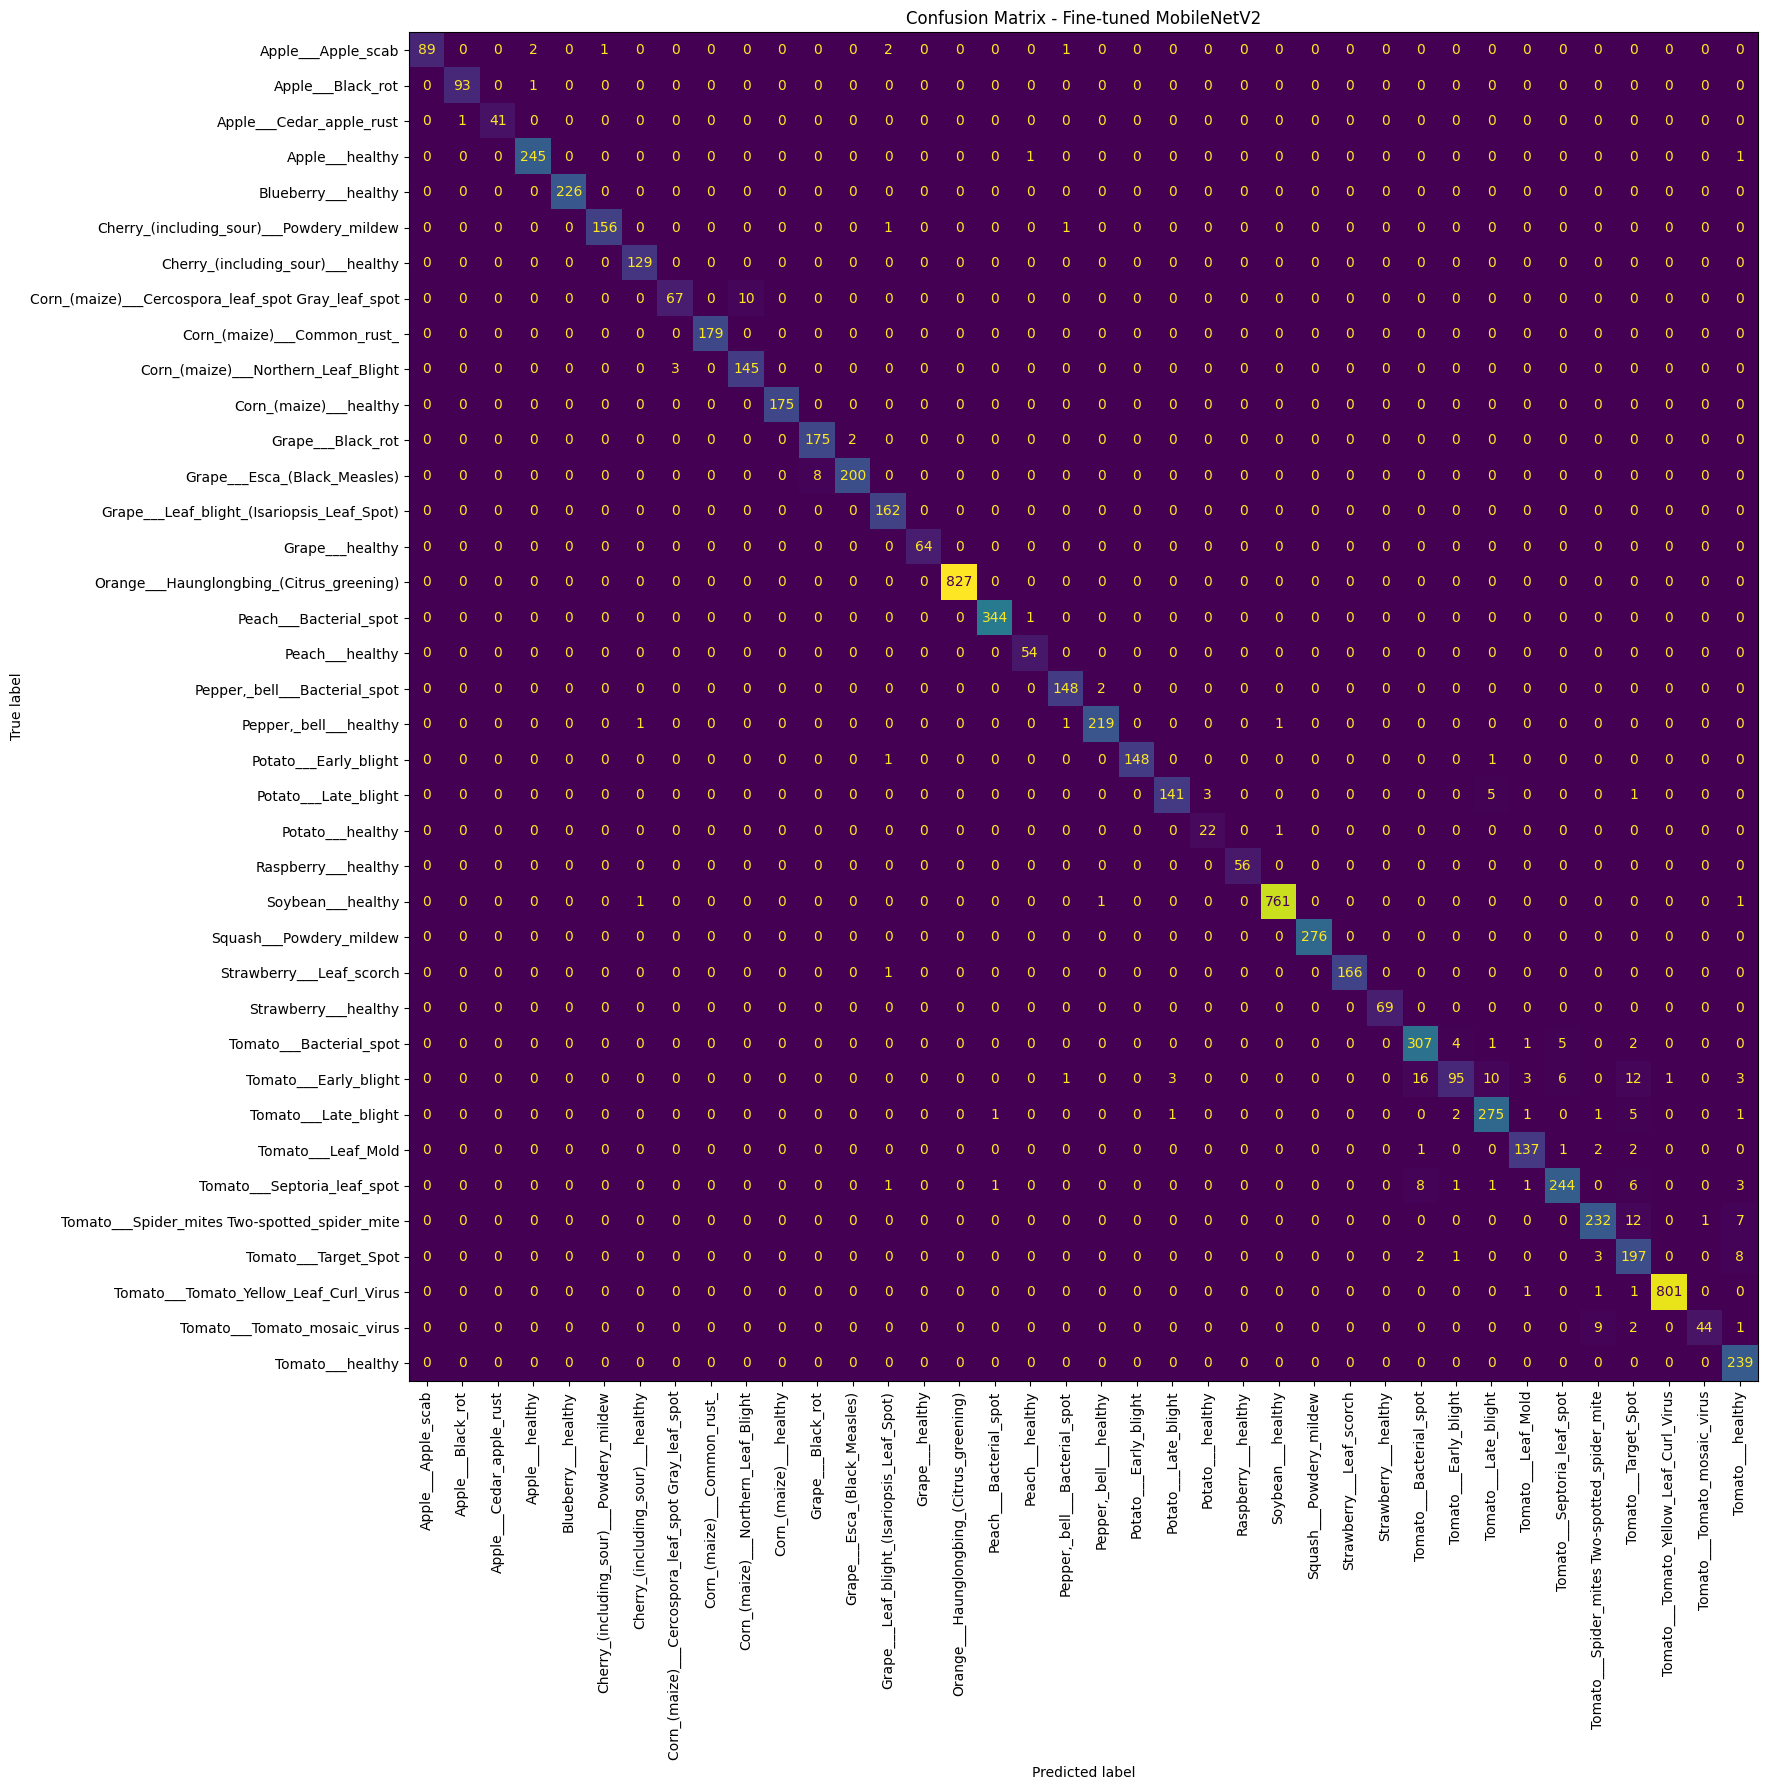

In [74]:
cm_ft = confusion_matrix(y_true_ft, y_pred_ft)

fig, ax = plt.subplots(figsize=(18, 18))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_ft,
    display_labels=class_names
)

disp.plot(
    ax=ax,
    xticks_rotation=90,
    colorbar=False
)

plt.title("Confusion Matrix - Fine-tuned MobileNetV2")
plt.tight_layout()
plt.show()

Fine-tuning improved overall generalization and reduced several major confusion patterns, particularly among visually similar corn diseases and Tomato Target Spot. However, performance decreased for certain classes such as Tomato Early Blight, indicating that improvements in overall accuracy do not necessarily translate into uniform improvements across all disease categories.

In [76]:
from collections import Counter

confusion_pairs_ft = Counter(
    (class_names[true_label], class_names[pred_label])
    for true_label, pred_label in zip(y_true_ft, y_pred_ft)
    if true_label != pred_label
)

for (true_class, predicted_class), count in confusion_pairs_ft.most_common(15):
    print(f"{true_class}  →  {predicted_class}: {count}")

Tomato___Early_blight  →  Tomato___Bacterial_spot: 16
Tomato___Early_blight  →  Tomato___Target_Spot: 12
Tomato___Spider_mites Two-spotted_spider_mite  →  Tomato___Target_Spot: 12
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot  →  Corn_(maize)___Northern_Leaf_Blight: 10
Tomato___Early_blight  →  Tomato___Late_blight: 10
Tomato___Tomato_mosaic_virus  →  Tomato___Spider_mites Two-spotted_spider_mite: 9
Grape___Esca_(Black_Measles)  →  Grape___Black_rot: 8
Tomato___Septoria_leaf_spot  →  Tomato___Bacterial_spot: 8
Tomato___Target_Spot  →  Tomato___healthy: 8
Tomato___Spider_mites Two-spotted_spider_mite  →  Tomato___healthy: 7
Tomato___Early_blight  →  Tomato___Septoria_leaf_spot: 6
Tomato___Septoria_leaf_spot  →  Tomato___Target_Spot: 6
Potato___Late_blight  →  Tomato___Late_blight: 5
Tomato___Bacterial_spot  →  Tomato___Septoria_leaf_spot: 5
Tomato___Late_blight  →  Tomato___Target_Spot: 5


Fine-tuned MobileNetV2 achieved 97.38% test accuracy, outperforming the custom CNN baseline of 95.52% by 1.86 percentage points. The macro F1-score also improved from 94.02% to 96.49%, indicating better overall class-wise performance. Error analysis showed substantial reductions in several confusion patterns, particularly among corn diseases. However, Tomato Early Blight remained a challenging class, with most of its errors being confused with other tomato diseases such as Bacterial Spot, Target Spot, and Late Blight.

In [77]:
def predict_disease(image_path):
    image = tf.keras.utils.load_img(
        image_path,
        target_size=(224, 224)
    )

    image_array = tf.keras.utils.img_to_array(image)
    image_array = image_array / 255.0
    image_array = np.expand_dims(image_array, axis=0)

    predictions = fine_tuned_model.predict(image_array, verbose=0)

    predicted_index = np.argmax(predictions[0])
    confidence = predictions[0][predicted_index]

    predicted_class = class_names[predicted_index]

    print("Predicted Disease:", predicted_class)
    print("Confidence:", f"{confidence * 100:.2f}%")

In [79]:
color_dir = "/content/PlantVillage-Dataset/color"

print("Dataset path:", color_dir)
print("Path exists:", os.path.exists(color_dir))

Dataset path: /content/PlantVillage-Dataset/color
Path exists: False


In [87]:
import random
import os

class_name = random.choice(class_names)

class_path = os.path.join(color_path, class_name)

image_name = random.choice(os.listdir(class_path))
image_path = os.path.join(class_path, image_name)

print("Actual Class:", class_name)
print("Image Path:", image_path)

predict_disease(image_path)

Actual Class: Tomato___Spider_mites Two-spotted_spider_mite
Image Path: /content/PlantVillage-Dataset/raw/color/Tomato___Spider_mites Two-spotted_spider_mite/91fc001b-f4dd-4ffb-af7c-2c7dd4f1c4ab___Com.G_SpM_FL 8822.JPG
Predicted Disease: Tomato___Spider_mites Two-spotted_spider_mite
Confidence: 84.88%


In [88]:
def predict_top3(image_path):
    image = tf.keras.utils.load_img(
        image_path,
        target_size=(224, 224)
    )

    image_array = tf.keras.utils.img_to_array(image)
    image_array = image_array / 255.0
    image_array = np.expand_dims(image_array, axis=0)

    predictions = fine_tuned_model.predict(image_array, verbose=0)[0]

    top3_indices = np.argsort(predictions)[-3:][::-1]

    print("Top 3 Predictions:\n")

    for rank, index in enumerate(top3_indices, start=1):
        print(
            f"{rank}. {class_names[index]} "
            f"→ {predictions[index] * 100:.2f}%"
        )

In [89]:
predict_top3(image_path)

Top 3 Predictions:

1. Tomato___Spider_mites Two-spotted_spider_mite → 84.88%
2. Tomato___Target_Spot → 10.97%
3. Tomato___healthy → 4.10%


###Single Image Prediction:
The fine-tuned MobileNetV2 correctly classified a sample image of Tomato Spider Mites with 84.88% confidence. The second-highest prediction was Tomato Target Spot with 10.97%, which is consistent with the confusion patterns observed during test-set error analysis.